# 03 · Correlaciones clima–agro — Campo Trebolares

¿Qué variables climáticas explican mejor los años buenos y malos?  
Cruce entre los scores agronómicos de cada campaña y las variables del año calendario correspondiente.

## 0 · Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
PROC = ROOT / 'data' / 'trebolares' / 'processed'

SCENARIOS = ['maize_early', 'maize_late', 'wheat', 'soy_first', 'soy_second']
LABELS = {
    'maize_early': 'Maíz temprano',
    'maize_late':  'Maíz tardío',
    'wheat':       'Trigo',
    'soy_first':   'Soja 1ª',
    'soy_second':  'Soja 2ª',
}

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 130})
print('ROOT:', ROOT)

ROOT: C:\Users\Usuario\OneDrive\appsheet\Antigravity\Proyecto ClimaData


## 1 · Carga y merge clima × agro

In [2]:
annual_climate = pd.read_parquet(PROC / 'climate_annual.parquet')

frames = []
for sc in SCENARIOS:
    cs = pd.read_parquet(PROC / f'agro_{sc}_campaign_summary.parquet')
    merged = cs.merge(annual_climate, left_on='campaign_start_year', right_on='year', how='left')
    merged['scenario'] = sc
    merged['scenario_label'] = LABELS[sc]
    frames.append(merged)

df = pd.concat(frames, ignore_index=True)

# Variables de interés
CLIMATE_VARS = [
    'precipitation_mm',
    'temp_mean_c',
    'temp_min_c',
    'temp_max_c',
    'precipitation_anomaly_pct',
]
AGRO_VARS = [
    'agro_score',
    'water_balance_mm',
    'critical_balance_mm',
    'precipitation_cycle_mm',
    'mean_temp_cycle_c',
    'critical_deficit_share',
]

print(f'Filas totales (5 escenarios × 24 campañas): {len(df)}')
print(df[['scenario_label', 'campaign_start_year', 'agro_score', 'precipitation_mm', 'temp_mean_c']].head(8).to_string(index=False))

Filas totales (5 escenarios × 24 campañas): 121
scenario_label  campaign_start_year  agro_score  precipitation_mm  temp_mean_c
 Maíz temprano                 2001        28.4           1142.79    15.947123
 Maíz temprano                 2002        21.6            746.42    15.992384
 Maíz temprano                 2003        20.1            477.86    17.060164
 Maíz temprano                 2004        36.2            840.05    16.592978
 Maíz temprano                 2005        19.5            558.77    16.329589
 Maíz temprano                 2006        53.5            728.83    16.832548
 Maíz temprano                 2007        22.8            764.34    15.239671
 Maíz temprano                 2008        22.8            664.41    16.950383


## 2 · Correlación de cada variable climática con el score (por cultivo)

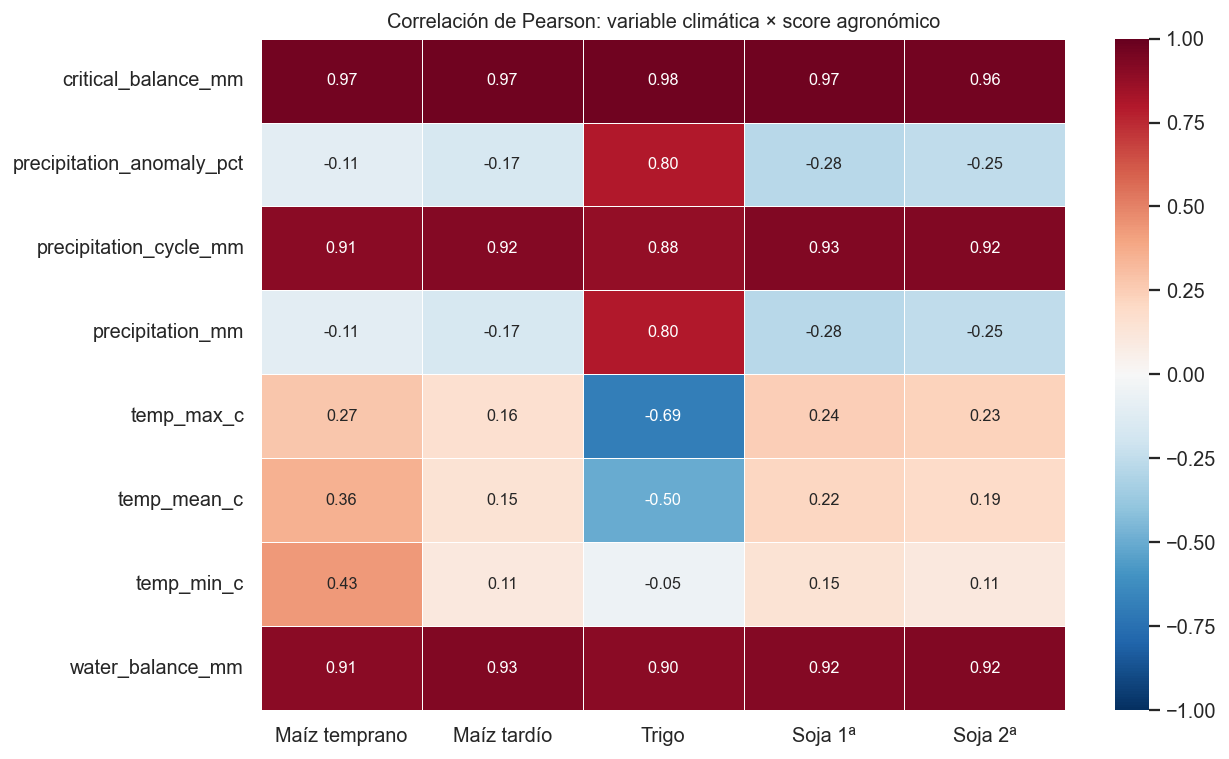

In [3]:
corr_rows = []
for sc in SCENARIOS:
    sub = df[df['scenario'] == sc]
    for var in CLIMATE_VARS + ['precipitation_cycle_mm', 'critical_balance_mm', 'water_balance_mm']:
        r = sub[['agro_score', var]].corr().iloc[0, 1]
        corr_rows.append({'scenario': LABELS[sc], 'variable': var, 'r': r})

corr_df = pd.DataFrame(corr_rows).pivot(index='variable', columns='scenario', values='r')
corr_df = corr_df[[LABELS[sc] for sc in SCENARIOS]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white', annot_kws={'size': 9}, ax=ax
)
ax.set_title('Correlación de Pearson: variable climática × score agronómico', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3 · Las 3 variables más correlacionadas con el score

In [4]:
all_vars = CLIMATE_VARS + ['precipitation_cycle_mm', 'critical_balance_mm', 'water_balance_mm']

for sc in SCENARIOS:
    sub = df[df['scenario'] == sc]
    corrs = {var: sub[['agro_score', var]].corr().iloc[0, 1] for var in all_vars}
    top3 = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
    print(f"{LABELS[sc]:20s}  " + '   '.join(f'{v}: {r:+.2f}' for v, r in top3))

Maíz temprano         critical_balance_mm: +0.97   water_balance_mm: +0.91   precipitation_cycle_mm: +0.91
Maíz tardío           critical_balance_mm: +0.97   water_balance_mm: +0.93   precipitation_cycle_mm: +0.92
Trigo                 critical_balance_mm: +0.98   water_balance_mm: +0.90   precipitation_cycle_mm: +0.88
Soja 1ª               critical_balance_mm: +0.97   precipitation_cycle_mm: +0.93   water_balance_mm: +0.92
Soja 2ª               critical_balance_mm: +0.96   water_balance_mm: +0.92   precipitation_cycle_mm: +0.92


## 4 · Score vs balance hídrico crítico — scatter por cultivo

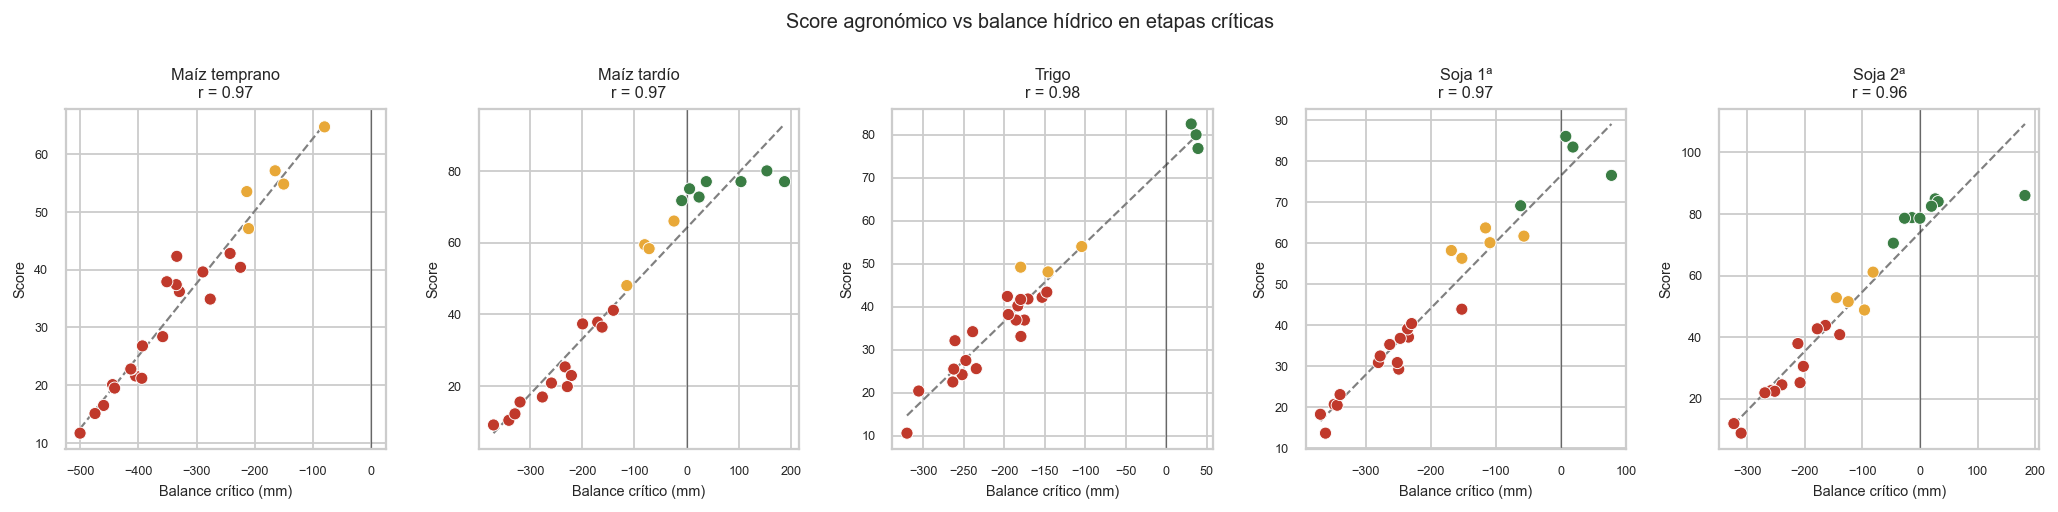

In [5]:
CLASS_COLORS = {'Favorable': '#3A7D44', 'Intermedia': '#E8A838', 'Restrictiva': '#C0392B'}
COLORS = {
    'maize_early': '#E8A838', 'maize_late': '#F4C97A',
    'wheat': '#8B6914', 'soy_first': '#3A7D44', 'soy_second': '#83C27B'
}

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 4), sharey=False)

for ax, sc in zip(axes, SCENARIOS):
    sub = df[df['scenario'] == sc]
    c = sub['campaign_class'].map(CLASS_COLORS)
    ax.scatter(sub['critical_balance_mm'], sub['agro_score'],
               c=c, s=45, edgecolors='white', linewidths=0.5, zorder=3)

    # Tendencia
    valid = sub[['critical_balance_mm', 'agro_score']].dropna()
    m, b = np.polyfit(valid['critical_balance_mm'], valid['agro_score'], 1)
    x_line = np.linspace(valid['critical_balance_mm'].min(), valid['critical_balance_mm'].max(), 100)
    ax.plot(x_line, m*x_line + b, color='gray', lw=1.2, ls='--')

    r = valid.corr().iloc[0, 1]
    ax.set_title(f'{LABELS[sc]}\nr = {r:.2f}', fontsize=9)
    ax.axvline(0, color='black', lw=0.7, alpha=0.5)
    ax.set_xlabel('Balance crítico (mm)', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Score agronómico vs balance hídrico en etapas críticas', fontsize=11)
plt.tight_layout()
plt.show()

## 5 · Anomalía de precipitación anual vs score (todos los cultivos)

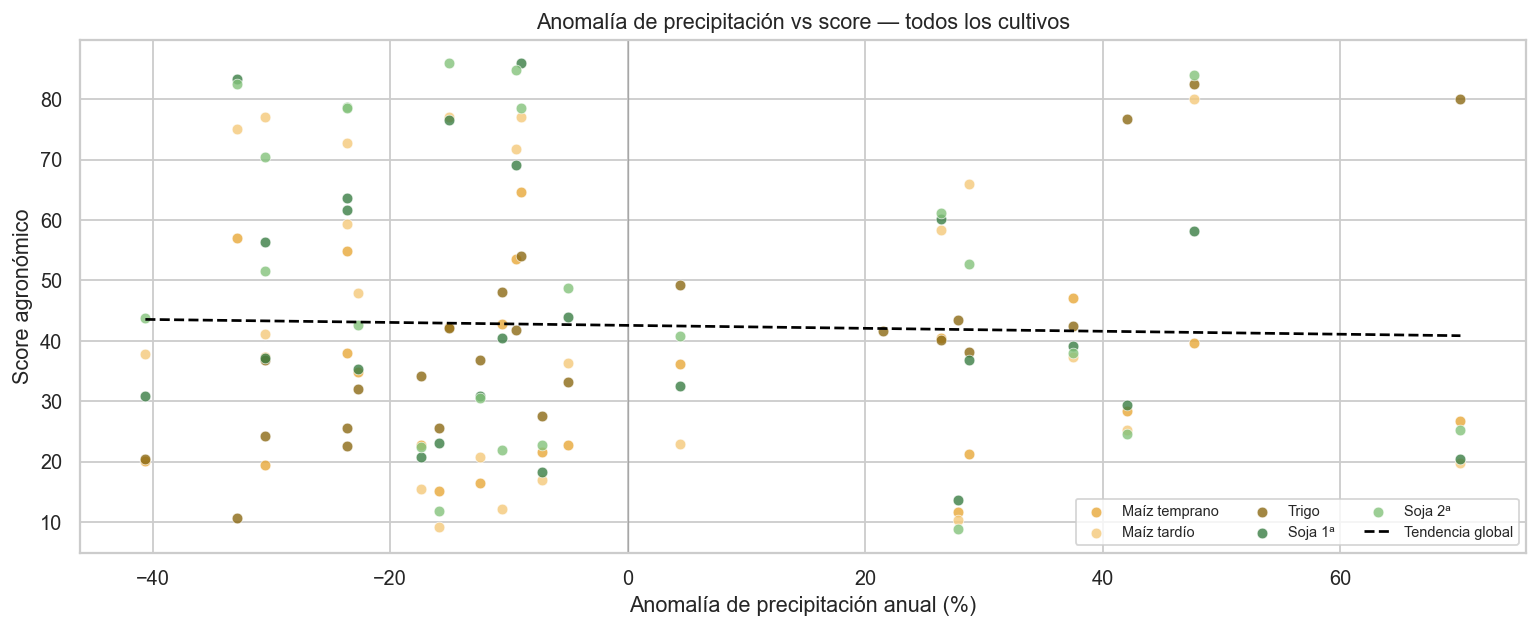

Correlación global anomalía precip. vs score: r = -0.033


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for sc in SCENARIOS:
    sub = df[df['scenario'] == sc]
    ax.scatter(
        sub['precipitation_anomaly_pct'], sub['agro_score'],
        color=COLORS[sc], label=LABELS[sc],
        s=35, edgecolors='white', linewidths=0.4, alpha=0.8, zorder=3
    )

# Tendencia global
all_valid = df[['precipitation_anomaly_pct', 'agro_score']].dropna()
m, b = np.polyfit(all_valid['precipitation_anomaly_pct'], all_valid['agro_score'], 1)
x_line = np.linspace(all_valid['precipitation_anomaly_pct'].min(), all_valid['precipitation_anomaly_pct'].max(), 100)
ax.plot(x_line, m*x_line + b, color='black', lw=1.5, ls='--', label='Tendencia global', zorder=4)

ax.axvline(0, color='gray', lw=0.8, alpha=0.5)
ax.set_xlabel('Anomalía de precipitación anual (%)')
ax.set_ylabel('Score agronómico')
ax.set_title('Anomalía de precipitación vs score — todos los cultivos')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

r_global = all_valid.corr().iloc[0, 1]
print(f'Correlación global anomalía precip. vs score: r = {r_global:.3f}')

## 6 · Temperatura media vs score — ¿el calor penaliza?

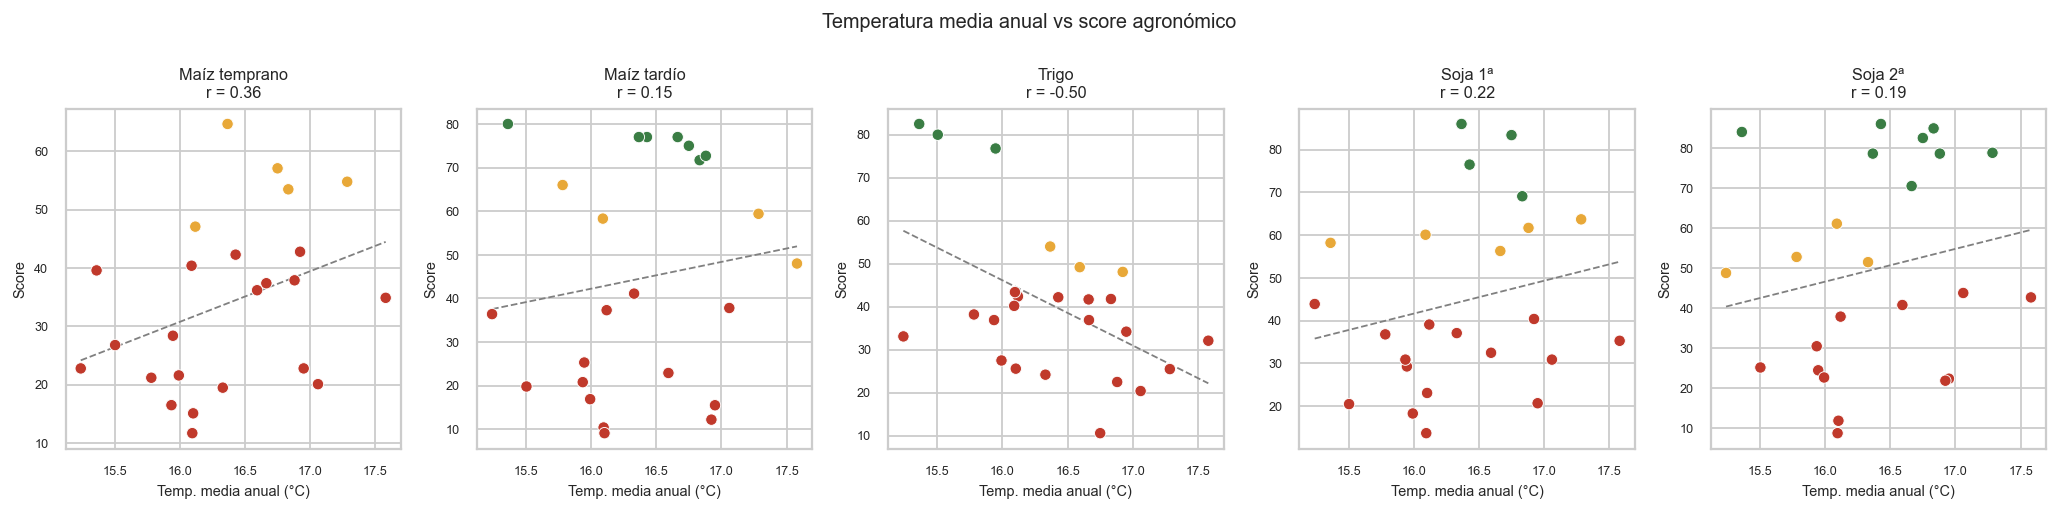

In [7]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 4), sharey=False)

for ax, sc in zip(axes, SCENARIOS):
    sub = df[df['scenario'] == sc]
    c = sub['campaign_class'].map(CLASS_COLORS)
    ax.scatter(sub['temp_mean_c'], sub['agro_score'],
               c=c, s=40, edgecolors='white', linewidths=0.5, zorder=3)

    valid = sub[['temp_mean_c', 'agro_score']].dropna()
    if len(valid) > 3:
        m, b = np.polyfit(valid['temp_mean_c'], valid['agro_score'], 1)
        x_line = np.linspace(valid['temp_mean_c'].min(), valid['temp_mean_c'].max(), 100)
        ax.plot(x_line, m*x_line + b, color='gray', lw=1, ls='--')

    r = valid.corr().iloc[0, 1]
    ax.set_title(f'{LABELS[sc]}\nr = {r:.2f}', fontsize=9)
    ax.set_xlabel('Temp. media anual (°C)', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Temperatura media anual vs score agronómico', fontsize=11)
plt.tight_layout()
plt.show()

## 7 · Matriz de correlaciones entre variables agro-climáticas (un cultivo de referencia)

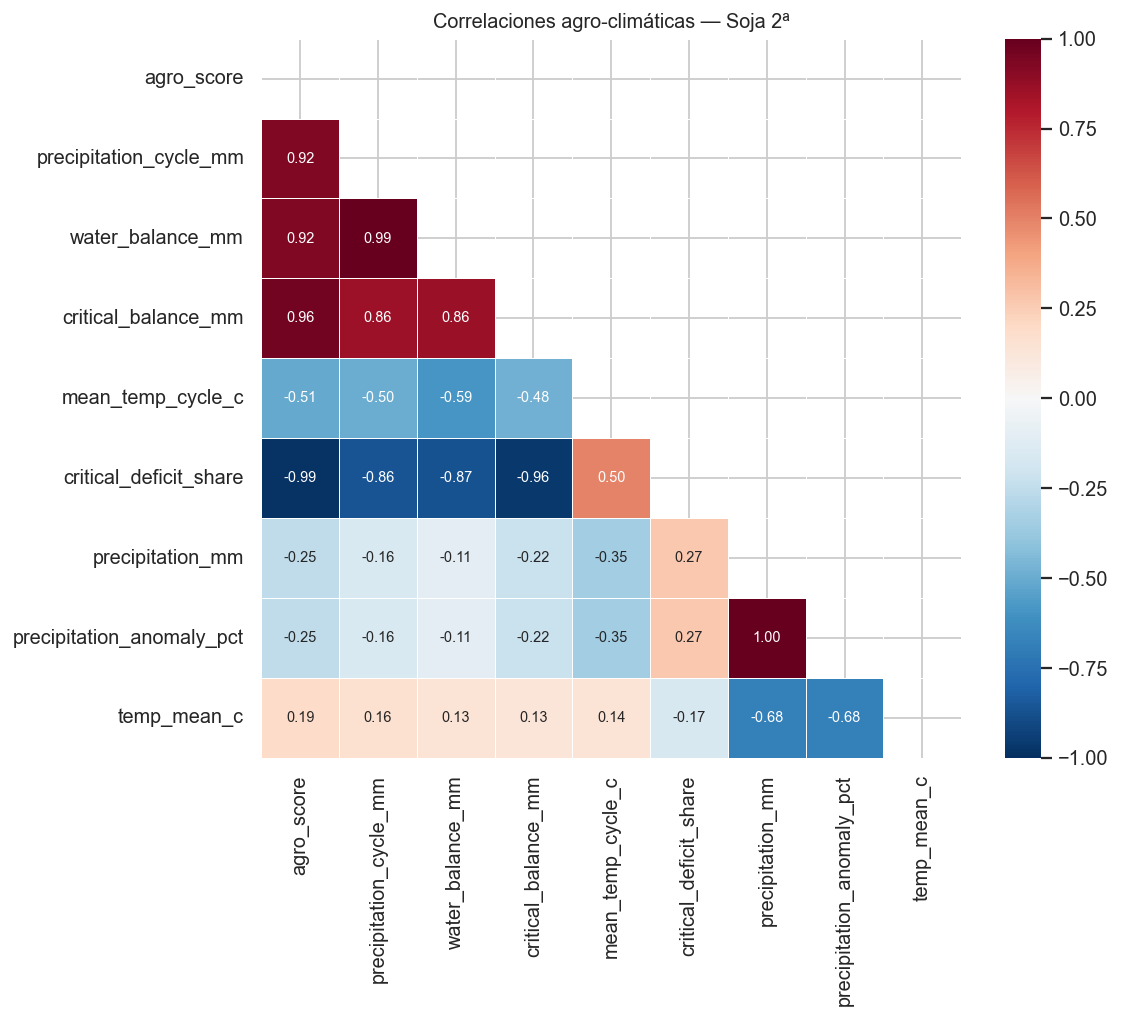

In [8]:
REF_SCENARIO = 'soy_second'  # soja de segunda — más variabilidad, mejor para correlaciones

sub = df[df['scenario'] == REF_SCENARIO][[
    'agro_score',
    'precipitation_cycle_mm',
    'water_balance_mm',
    'critical_balance_mm',
    'mean_temp_cycle_c',
    'critical_deficit_share',
    'precipitation_mm',
    'precipitation_anomaly_pct',
    'temp_mean_c',
]].dropna()

corr_matrix = sub.corr()

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white', annot_kws={'size': 8}, ax=ax
)
ax.set_title(f'Correlaciones agro-climáticas — {LABELS[REF_SCENARIO]}', fontsize=11)
plt.tight_layout()
plt.show()

## 8 · Resumen interpretativo

In [9]:
print('RESUMEN — Correlaciones clima × score agronómico (Campo Trebolares)')
print('='*65)
print()

key_vars = ['critical_balance_mm', 'water_balance_mm', 'precipitation_cycle_mm', 'precipitation_mm']

for sc in SCENARIOS:
    sub = df[df['scenario'] == sc]
    corrs = [(var, sub[['agro_score', var]].dropna().corr().iloc[0, 1]) for var in key_vars]
    best_var, best_r = max(corrs, key=lambda x: abs(x[1]))
    print(f'  {LABELS[sc]:20s}  mejor predictor: {best_var} (r={best_r:+.2f})')

print()
print('Nota: el balance hídrico en etapas críticas (critical_balance_mm)')
print('es el predictor más consistente del score agronómico en todos los cultivos.')

RESUMEN — Correlaciones clima × score agronómico (Campo Trebolares)

  Maíz temprano         mejor predictor: critical_balance_mm (r=+0.97)
  Maíz tardío           mejor predictor: critical_balance_mm (r=+0.97)
  Trigo                 mejor predictor: critical_balance_mm (r=+0.98)
  Soja 1ª               mejor predictor: critical_balance_mm (r=+0.97)
  Soja 2ª               mejor predictor: critical_balance_mm (r=+0.96)

Nota: el balance hídrico en etapas críticas (critical_balance_mm)
es el predictor más consistente del score agronómico en todos los cultivos.
